<a href="https://colab.research.google.com/github/KalininGroup/camm_hackathon/blob/k4my4r/docs/day_4_11072025/CAMM_Hackathon_4_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#XRD Data from Dr Katherine Page

In [ ]:
# !gdown --fuzzy https://drive.google.com/file/d/1Zzknr5yjvzTgPCMY7PD4YjcRJoecBK8z/view?usp=sharing

In [ ]:
# !unzip '/content/Data for Hackathon.zip'

In [1]:
import os, textwrap

BASE = "Data for Hackathon"
for d in sorted(os.listdir(BASE)):
    p = os.path.join(BASE, d)
    mark = "📁" if os.path.isdir(p) else "📄"
    print(f"{mark} {d}")


📁 Cifs
📄 Info.txt
📁 PrNdGdYbLu2 Ti2 O7
📁 PrSmGdHoLu2 Ti2 O7
📁 SmEuGdTbDy2 Ti2 O7
📁 Standard Data


###  Accessing and Exploring the XRD Data

Each folder inside `/content/Data` contains XRD scans for a different material:

```
/content/Data
 ├── PrNdGdYbLu2 Ti2 O7/
 ├── PrSmGdHoLu2 Ti2 O7/
 ├── SmEuGdTbDy2 Ti2 O7/
 ├── Standard Data/
 └── Cifs/   ← structure models for fitting
```

#### 🧩 What you need to do

1. **Preview the data** – load and plot an XRD pattern from one of the sample folders.
2. **Compare patterns** – look at how the peaks shift between different samples.
3. **Use the CIFs** – later, you can use the `.cif` files in `/content/Data/Cifs` for model fitting (for example, in DARA).

#### 🧠 Steps

1. Run the next cell to define a **small function** that reads `.xrdml` files (the standard PANalytical format).
2. Change the folder name (for example, to `"SmEuGdTbDy2 Ti2 O7"`) and **run the next cell** to:

   * Plot one scan from that folder.
   * Optionally compare the first scan from all sample folders.

#### ⚙️ Notes

* The `Standard Data` folder is a **reference pattern** — use it to refine or fix your instrument parameters before fitting complex samples..
* Once you verify the data loads correctly, you can move to the **DARA refinement notebook** and use these same blocks to code there to load data in there.

In [2]:
from IPython.display import Markdown

path = "Data for Hackathon/Info.txt"
with open(path) as f:
    content = f.read()

display(Markdown(f"### ℹ️ Dataset Information\n\n{content}"))


### ℹ️ Dataset Information

The raw X-Ray diffraction data are in the folders labelled by each sample name. Each file has the temperature that the measurement was taken at. For each a series of scans from 25-1175 C was taken at 50 C intervals.

A measured silicon standard is provided which can be used for making an instrument parameter file.

For Samples the compositions are as follows

Sm 2/5 Eu 2/5 Gd 2/5 Tb 2/5 Dy 2/5 Ti 2 O 7

Pr 2/5 Sm 2/5 Gd 2/5 Ho 2/5 Lu 2/5 Ti 2 O 7

Pr 2/5 Nd 2/5 Gd 2/5 Yb 2/5 Lu 2/5 Ti 2 O 7

For the cifs that were provided there is Gadolinium Titanate which can act as a baseline for adding elements and a Hybrid High Entropy Structure that has all the elements added into it as well as a degree of site inversion added in between the rare earth elements and the titanium.

In [3]:
# Minimal XRDML -> DataFrame
import xml.etree.ElementTree as ET, numpy as np, pandas as pd

def read_xrdml_df(path, scan_index=0):
    r = ET.parse(path).getroot(); ns = {"x": r.tag.split('}')[0].strip('{')}
    # prefer dataPoints blocks
    dp = r.find(".//x:dataPoints", ns) or r.find(".//x:scan//x:dataPoints", ns)
    if dp is None: raise ValueError("No dataPoints found")
    ints = (dp.findtext("x:intensities", namespaces=ns)
            or dp.findtext("x:counts", namespaces=ns) or "").strip()
    I = np.fromstring(ints, sep=' ')
    pos = dp.find("x:positions", ns)
    if pos is not None:
        s = pos.findtext("x:startPosition", namespaces=ns); e = pos.findtext("x:endPosition", namespaces=ns)
        if s and e: x = np.linspace(float(s), float(e), I.size)
        else:
            txt = (pos.text or "").strip(); x = np.fromstring(txt, sep=' ') if txt else None
    else:
        s = dp.findtext("x:startPosition", namespaces=ns); e = dp.findtext("x:endPosition", namespaces=ns)
        x = np.linspace(float(s), float(e), I.size) if s and e else None
    if x is None or I.size != x.size: raise ValueError("Could not reconstruct 2θ")
    return pd.DataFrame({"2theta_deg": x, "intensity": I})


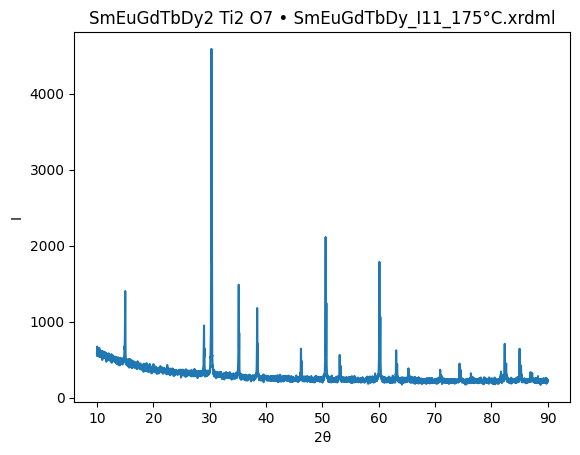

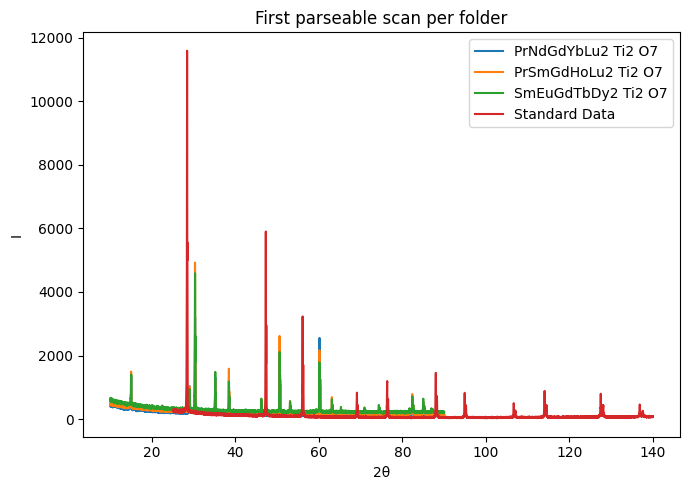

In [5]:
import os, matplotlib.pyplot as plt

BASE = "Data for Hackathon"
SAMPLE_FOLDERS = [
    "PrNdGdYbLu2 Ti2 O7",
    "PrSmGdHoLu2 Ti2 O7",
    "SmEuGdTbDy2 Ti2 O7",
    "Standard Data",
]

# --- A) Preview ONE folder (change the name below) ---
FOLDER = "SmEuGdTbDy2 Ti2 O7"
p = os.path.join(BASE, FOLDER)
f = next((fn for fn in sorted(os.listdir(p)) if fn.lower().endswith(".xrdml")), None)
df = read_xrdml_df(os.path.join(p, f))
plt.plot(df["2theta_deg"], df["intensity"]); plt.xlabel("2θ"); plt.ylabel("I"); plt.title(f"{FOLDER} • {f}"); plt.show()

# --- B) Quick compare (first parseable file from each folder) ---
plt.figure(figsize=(7,5))
for name in SAMPLE_FOLDERS:
    q = os.path.join(BASE, name)
    files = [fn for fn in sorted(os.listdir(q)) if fn.lower().endswith(".xrdml")]
    for fn in files:
        try:
            df = read_xrdml_df(os.path.join(q, fn)); plt.plot(df["2theta_deg"], df["intensity"], label=name); break
        except Exception:
            continue
plt.xlabel("2θ"); plt.ylabel("I"); plt.title("First parseable scan per folder"); plt.legend(); plt.tight_layout(); plt.show()


cif

In [116]:
from pymatgen.core import Structure
import nglview as nv

# Path to your CIF file
cif_path = "/Users/kbarakat/Library/CloudStorage/OneDrive-UniversityofTennessee/vs_code/camm_hackathon/docs/day_4_11072025/Data for Hackathon/Cifs/Gadolinium Titanate Pyro.cif"

# Load structure
structure = Structure.from_file(cif_path)

# Show structure
view = nv.show_pymatgen(structure)
view.add_unitcell()      # draws the cell box
view.camera = "orthographic"
view

NGLWidget()

In [117]:
from pymatgen.core import Structure
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

structure = Structure.from_file(cif_path)

# Basic data
print("Formula:", structure.formula)
print("Lattice parameters:", structure.lattice)
print("Density (g/cm³):", structure.density)

# Symmetry
analyzer = SpacegroupAnalyzer(structure)
print("Space group:", analyzer.get_space_group_symbol(), analyzer.get_space_group_number())

# Wyckoff positions
sym_data = analyzer.get_symmetry_dataset()
print("Wyckoff positions:", sym_data["wyckoffs"])


Formula: Gd16 Ti16 O56
Lattice parameters: 10.184300 0.000000 0.000000
-0.000000 10.184300 0.000000
0.000000 0.000000 10.184300
Density (g/cm³): 6.567607403006006 g cm^-3
Space group: Fd-3m 227
Wyckoff positions: ['c', 'c', 'c', 'c', 'c', 'c', 'c', 'c', 'c', 'c', 'c', 'c', 'c', 'c', 'c', 'c', 'd', 'd', 'd', 'd', 'd', 'd', 'd', 'd', 'd', 'd', 'd', 'd', 'd', 'd', 'd', 'd', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'f', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a']


/var/folders/vg/6nvxw8xn77s4z_kb5c3hz38w0000gp/T/ipykernel_58814/862458170.py:17: DeprecationWarning: dict interface is deprecated. Use attribute interface instead
  print("Wyckoff positions:", sym_data["wyckoffs"])


Analysis

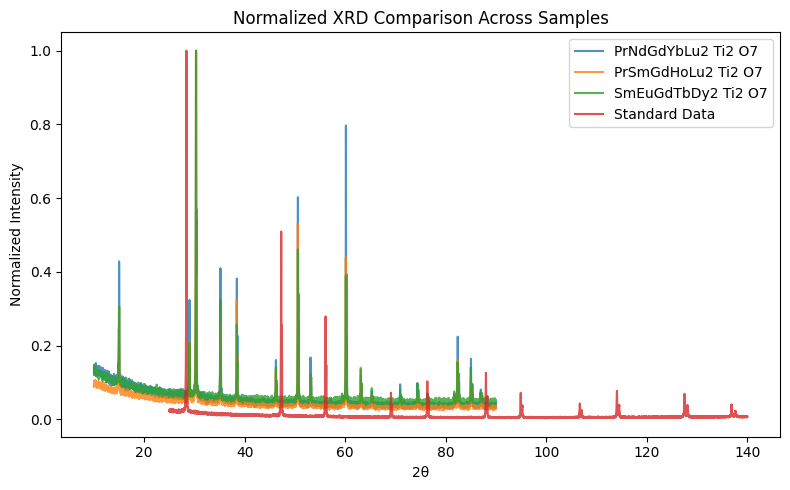

In [10]:
df["intensity_norm"] = df["intensity"] / df["intensity"].max()

plt.figure(figsize=(8,5))

for name in SAMPLE_FOLDERS:
    q = os.path.join(BASE, name)
    files = [fn for fn in sorted(os.listdir(q)) if fn.lower().endswith(".xrdml")]
    for fn in files:
        try:
            df = read_xrdml_df(os.path.join(q, fn))
            df["intensity_norm"] = df["intensity"] / df["intensity"].max()
            plt.plot(df["2theta_deg"], df["intensity_norm"], label=name, alpha=0.8)
            break
        except:
            continue

plt.xlabel("2θ")
plt.ylabel("Normalized Intensity")
plt.title("Normalized XRD Comparison Across Samples")
plt.legend()
plt.tight_layout()
plt.show()


<Figure size 700x500 with 0 Axes>

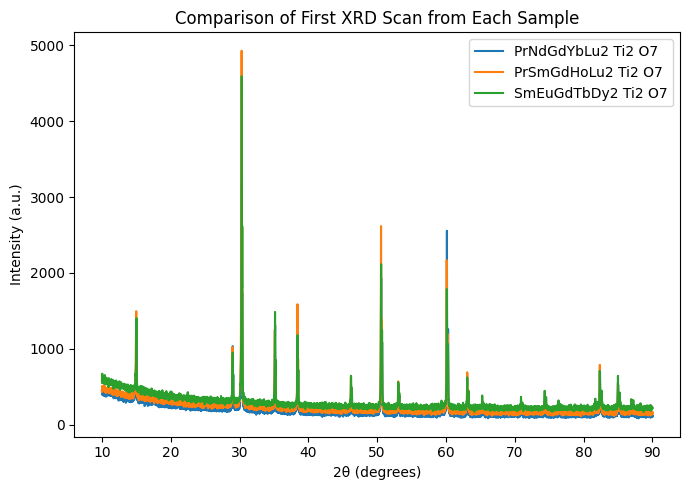

In [22]:
plt.figure(figsize=(7,5))

BASE = "Data for Hackathon"   # your folder in the screenshot

SAMPLE_FOLDERS = [
    "PrNdGdYbLu2 Ti2 O7",
    "PrSmGdHoLu2 Ti2 O7",
    "SmEuGdTbDy2 Ti2 O7",
    #"Standard Data",
]

plt.figure(figsize=(7,5))

for name in SAMPLE_FOLDERS:
    folder_path = os.path.join(BASE, name)
    files = [fn for fn in sorted(os.listdir(folder_path)) if fn.lower().endswith(".xrdml")]

    for fn in files:
        try:
            df = read_xrdml_df(os.path.join(folder_path, fn))
            plt.plot(df["2theta_deg"], df["intensity"], label=name)
            break
        except:
            continue

plt.xlabel("2θ (degrees)")
plt.ylabel("Intensity (a.u.)")
plt.title("Comparison of First XRD Scan from Each Sample")
plt.legend()
plt.tight_layout()
plt.show()


PCA

In [28]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

# ---- your data layout
BASE = Path("Data for Hackathon")
SAMPLE_FOLDERS = [
    "PrNdGdYbLu2 Ti2 O7",
    "PrSmGdHoLu2 Ti2 O7",
    "SmEuGdTbDy2 Ti2 O7",
    "Standard Data",
]

# ---- common 2θ grid for all scans (edit if your range differs)
TT_MIN, TT_MAX, TT_STEP = 25.0, 90.0, 0.02
TT_GRID = np.arange(TT_MIN, TT_MAX + TT_STEP/2, TT_STEP)

def normalize(y, mode="max"):
    y = np.asarray(y, float)
    if mode == "max":
        m = np.nanmax(y)
        return y / m if m > 0 else y
    if mode == "area":
        a = np.trapz(y, dx=TT_STEP)
        return y / a if a > 0 else y
    return y


In [29]:
def load_first_scan(folder: Path):
    # find first .xrdml we can parse
    for fn in sorted(folder.glob("*.xrdml")):
        try:
            df = read_xrdml_df(str(fn))
            # keep only within common grid bounds
            m = (df["2theta_deg"] >= TT_MIN) & (df["2theta_deg"] <= TT_MAX)
            x = df.loc[m, "2theta_deg"].to_numpy()
            y = df.loc[m, "intensity"].to_numpy()
            if len(x) < 10:
                continue
            # resample onto common grid
            y_grid = np.interp(TT_GRID, x, y, left=0.0, right=0.0)
            y_grid = normalize(y_grid, mode="max")
            return y_grid, fn.name
        except Exception:
            continue
    return None, None

X, labels, files = [], [], []

for name in SAMPLE_FOLDERS:
    y_grid, fname = load_first_scan(BASE / name)
    if y_grid is not None:
        X.append(y_grid)
        labels.append(name)
        files.append(fname)

X = np.vstack(X)  # shape: (n_samples, n_points)
print("Matrix shape:", X.shape)
list(zip(labels, files))[:5]


Matrix shape: (4, 3251)


[('PrNdGdYbLu2 Ti2 O7', 'PrNdGdYbLu_I11_175°C.xrdml'),
 ('PrSmGdHoLu2 Ti2 O7', 'PrSmGdHoLu_I11_175°C.xrdml'),
 ('SmEuGdTbDy2 Ti2 O7', 'SmEuGdTbDy_I11_175°C.xrdml'),
 ('Standard Data',
  '2023-11-13 - HTXRD - Silicon - PDS + FASS - 04 Soller - 1_4 div - 10 mask - 1_2 AS - HT Stage.xrdml')]

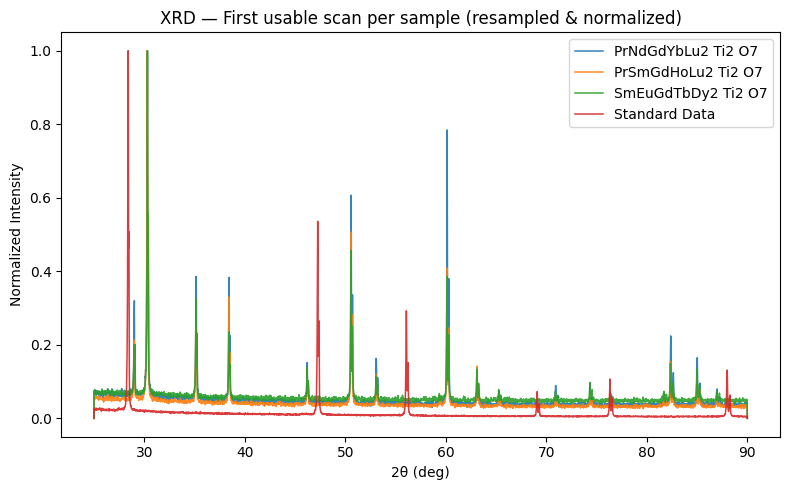

In [30]:
plt.figure(figsize=(8,5))
for y, name in zip(X, labels):
    plt.plot(TT_GRID, y, label=name, lw=1.1, alpha=0.9)
plt.xlabel("2θ (deg)"); plt.ylabel("Normalized Intensity")
plt.title("XRD — First usable scan per sample (resampled & normalized)")
plt.legend()
plt.tight_layout(); plt.show()


Explained variance (PC1–PC3): [0.9027 0.0539 0.0434]


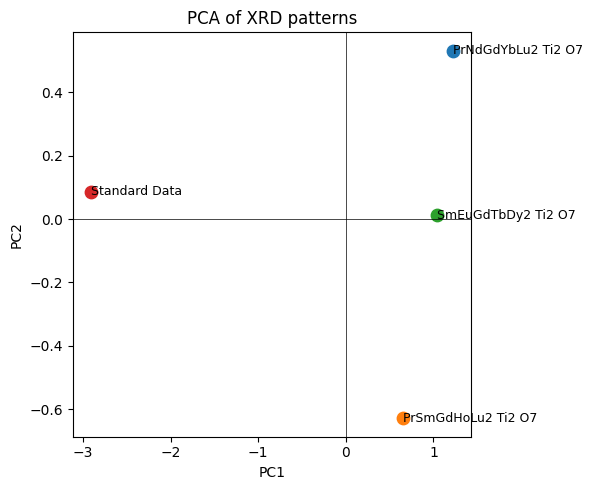

In [31]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3, random_state=0)
X_pca = pca.fit_transform(X)

print("Explained variance (PC1–PC3):", np.round(pca.explained_variance_ratio_[:3], 4))

# 2-D scatter of PC1 vs PC2
plt.figure(figsize=(6,5))
for (x, y), name in zip(X_pca[:, :2], labels):
    plt.scatter(x, y, s=80)
    plt.text(x, y, name, fontsize=9, ha='left', va='center')
plt.axhline(0, lw=0.5, color='k'); plt.axvline(0, lw=0.5, color='k')
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("PCA of XRD patterns")
plt.tight_layout(); plt.show()


all

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path("Data for Hackathon")
SAMPLE_FOLDERS = [
    "PrNdGdYbLu2 Ti2 O7",
    "PrSmGdHoLu2 Ti2 O7",
    "SmEuGdTbDy2 Ti2 O7",
    "Standard Data",
]

TT_MIN, TT_MAX, TT_STEP = 25.0, 90.0, 0.02
TT_GRID = np.arange(TT_MIN, TT_MAX + TT_STEP/2, TT_STEP)

def normalize(y):
    y = np.asarray(y)
    m = np.max(y)
    return y / m if m > 0 else y

X = []          # matrix (all measurements)
labels = []     # sample group labels
filenames = []  # specific file names

for folder in SAMPLE_FOLDERS:
    folder_path = BASE / folder
    xrd_files = list(folder_path.glob("*.xrdml"))

    for fn in xrd_files:
        try:
            df = read_xrdml_df(str(fn))
            m = (df["2theta_deg"] >= TT_MIN) & (df["2theta_deg"] <= TT_MAX)
            x = df.loc[m, "2theta_deg"].values
            y = df.loc[m, "intensity"].values
            if len(x) < 10: 
                continue
            
            y_grid = np.interp(TT_GRID, x, y, left=0, right=0)
            y_grid = normalize(y_grid)

            X.append(y_grid)
            labels.append(folder)
            filenames.append(fn.name)

        except Exception:
            continue

X = np.vstack(X)
print("Total scans loaded:", len(X))
print("Matrix shape:", X.shape)



Total scans loaded: 73
Matrix shape: (73, 3251)


In [37]:
from sklearn.decomposition import PCA

pca = PCA(n_components=4, random_state=0)
X_pca = pca.fit_transform(X)

print("Explained variance (PC1–PC3):", np.round(pca.explained_variance_ratio_[:3], 4))


Explained variance (PC1–PC3): [0.3645 0.2022 0.0844]


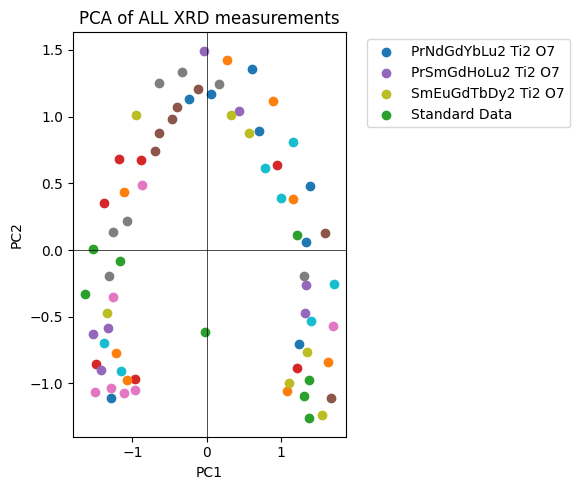

In [38]:
plt.figure(figsize=(6,5))
for (x, y), sample in zip(X_pca[:, :2], labels):
    plt.scatter(x, y, label=sample)

# group legend without duplicates
handles, unique = [], []
for handle, name in zip(*plt.gca().get_legend_handles_labels()):
    if name not in unique:
        handles.append(handle)
        unique.append(name)

plt.legend(handles, unique, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.axhline(0, lw=0.5, color='k')
plt.axvline(0, lw=0.5, color='k')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of ALL XRD measurements")
plt.tight_layout()
plt.show()


PCA on seperate folders

In [39]:
BASE = Path("Data for Hackathon")
SAMPLE_FOLDERS = [
    "PrNdGdYbLu2 Ti2 O7",
    "PrSmGdHoLu2 Ti2 O7",
    "SmEuGdTbDy2 Ti2 O7",
    "Standard Data",
]

TT_MIN, TT_MAX, TT_STEP = 25.0, 90.0, 0.02
TT_GRID = np.arange(TT_MIN, TT_MAX + TT_STEP/2, TT_STEP)

def normalize(y):
    y = np.asarray(y)
    m = np.max(y)
    return y / m if m > 0 else y



📂 PrNdGdYbLu2 Ti2 O7
Explained variance: [0.4111 0.2225]


/var/folders/vg/6nvxw8xn77s4z_kb5c3hz38w0000gp/T/ipykernel_58814/1335495254.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab20', len(filenames_local))


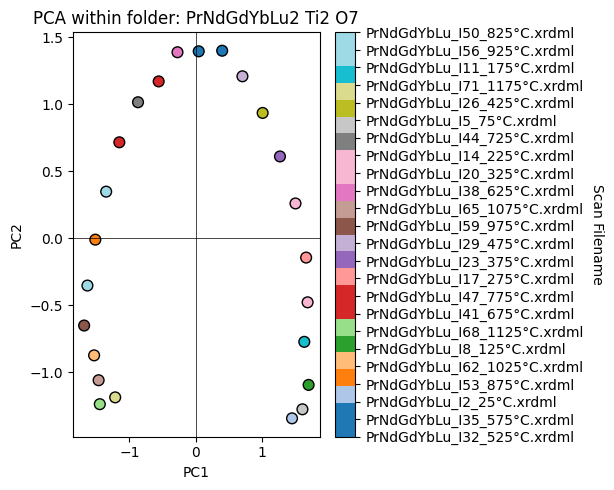


📂 PrSmGdHoLu2 Ti2 O7
Explained variance: [0.435  0.2343]


/var/folders/vg/6nvxw8xn77s4z_kb5c3hz38w0000gp/T/ipykernel_58814/1335495254.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab20', len(filenames_local))


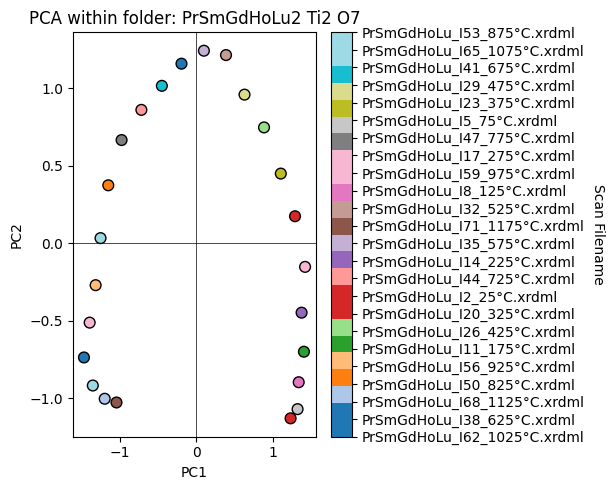


📂 SmEuGdTbDy2 Ti2 O7
Explained variance: [0.4057 0.2332]


/var/folders/vg/6nvxw8xn77s4z_kb5c3hz38w0000gp/T/ipykernel_58814/1335495254.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab20', len(filenames_local))


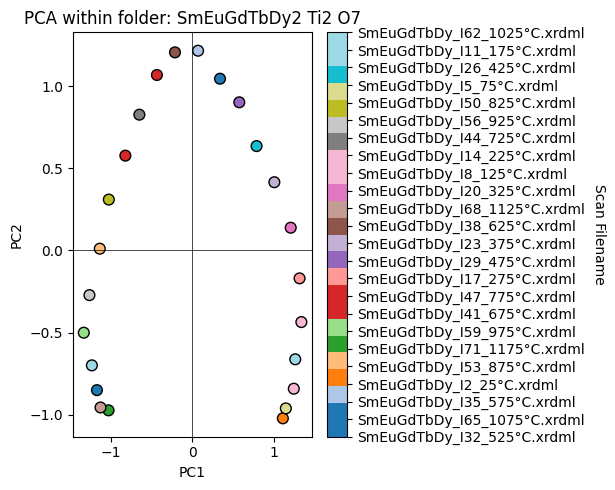

Skipping Standard Data — not enough valid scans.


In [42]:
from matplotlib.cm import get_cmap
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

for folder in SAMPLE_FOLDERS:

    folder_path = BASE / folder
    xrd_files = list(folder_path.glob("*.xrdml"))

    X_local = []
    filenames_local = []

    for fn in xrd_files:
        try:
            df = read_xrdml_df(str(fn))
            mask = (df["2theta_deg"] >= TT_MIN) & (df["2theta_deg"] <= TT_MAX)
            x = df.loc[mask, "2theta_deg"].values
            y = df.loc[mask, "intensity"].values
            if len(x) < 10:
                continue

            y_grid = np.interp(TT_GRID, x, y, left=0, right=0)
            y_grid = normalize(y_grid)

            X_local.append(y_grid)
            filenames_local.append(fn.name)

        except Exception:
            continue

    if len(X_local) < 2:
        print(f"Skipping {folder} — not enough valid scans.")
        continue

    X_local = np.vstack(X_local)

    # Run PCA inside this folder only
    pca = PCA(n_components=2, random_state=0)
    X_pca_local = pca.fit_transform(X_local)

    print(f"\n📂 {folder}")
    print("Explained variance:", np.round(pca.explained_variance_ratio_, 4))

    # ---------- PLOT for THIS FOLDER ----------
    plt.figure(figsize=(6,5))

    idx = np.arange(len(filenames_local))
    cmap = get_cmap('tab20', len(filenames_local))

    sc = plt.scatter(X_pca_local[:,0], X_pca_local[:,1], 
                     c=idx, cmap=cmap, s=60, edgecolor='k')

    plt.axhline(0, lw=0.5, color='k')
    plt.axvline(0, lw=0.5, color='k')
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"PCA within folder: {folder}")

    cbar = plt.colorbar(sc, ticks=idx)
    cbar.set_label("Scan Filename", rotation=270, labelpad=15)
    cbar.set_ticklabels(filenames_local)

    plt.tight_layout()
    plt.show()


Line spread along PC1 → Intensity ratio variation (texture)

Line spread along PC2 → Peak position shifts (strain / temperature)

In [59]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import umap.umap_ as umap

In [49]:
X_scaled = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=10).fit_transform(X_scaled)

kmeans = KMeans(n_clusters=3).fit(X_pca)
labels = kmeans.labels_


In [50]:
X_scaled = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=10).fit_transform(X_scaled)

kmeans = KMeans(n_clusters=3).fit(X_pca)
labels = kmeans.labels_


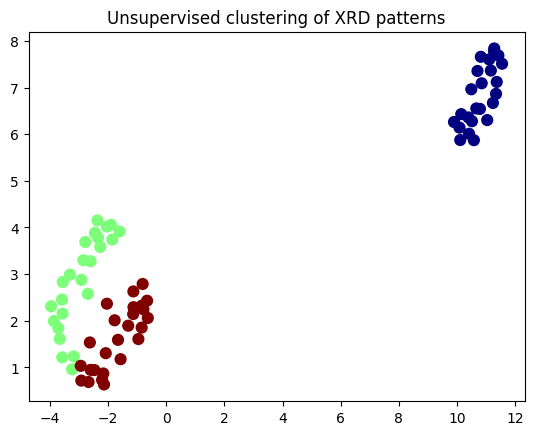

In [64]:
X_umap = umap.UMAP(n_neighbors=10, min_dist=0.1).fit_transform(X_scaled)

plt.scatter(X_umap[:,0], X_umap[:,1], c=labels, cmap='jet', s=60)
plt.title("Unsupervised clustering of XRD patterns")
plt.show()



In [65]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

BASE = Path("Data for Hackathon")

SAMPLE_FOLDERS = [
    "PrNdGdYbLu2 Ti2 O7",
    "PrSmGdHoLu2 Ti2 O7",
    "SmEuGdTbDy2 Ti2 O7",
    "Standard Data",
]

# XRD interpolation region
TT_MIN, TT_MAX = 10, 80
TT_GRID = np.linspace(TT_MIN, TT_MAX, 1500)   # uniform grid of angles

def normalize(v):
    v = np.array(v)
    return v / v.max() if v.max() > 0 else v


In [66]:
X = []
labels_composition = []
file_names = []

for folder in SAMPLE_FOLDERS:
    folder_path = BASE / folder
    xrd_files = sorted([fn for fn in folder_path.glob("*.xrdml")])

    for fn in xrd_files:
        try:
            df = read_xrdml_df(str(fn))

            # restrict region
            mask = (df["2theta_deg"] >= TT_MIN) & (df["2theta_deg"] <= TT_MAX)
            x = df.loc[mask, "2theta_deg"].values
            y = df.loc[mask, "intensity"].values
            if len(x) < 10:
                continue

            # interpolate to uniform grid + normalize
            y_grid = np.interp(TT_GRID, x, y, left=0, right=0)
            y_grid = normalize(y_grid)

            X.append(y_grid)
            labels_composition.append(folder)
            file_names.append(fn.name)
        except Exception:
            continue

X = np.vstack(X)
print(f"✅ Loaded dataset shape: {X.shape}")
print(f"✅ Number of scans: {len(file_names)}")


✅ Loaded dataset shape: (73, 1500)
✅ Number of scans: 73


Explained variance: [0.786 0.058]


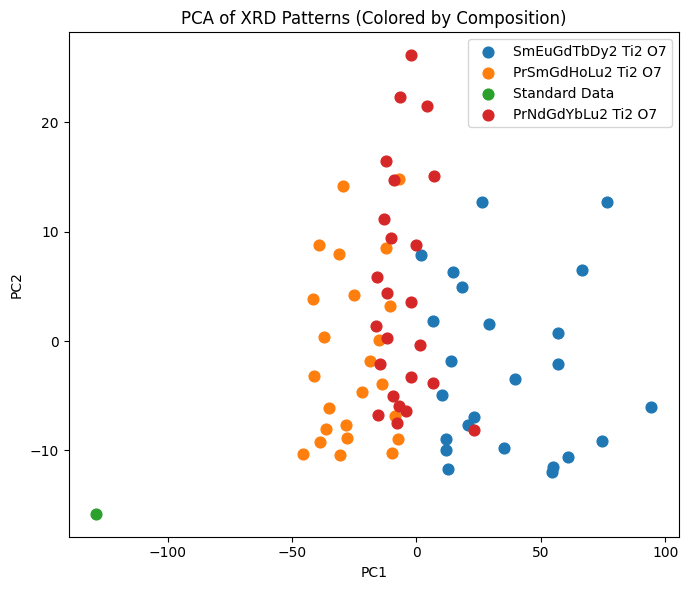

In [67]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

expl = np.round(pca.explained_variance_ratio_, 3)
print("Explained variance:", expl)

plt.figure(figsize=(7,6))
for comp in set(labels_composition):
    mask = np.array(labels_composition) == comp
    plt.scatter(X_pca[mask,0], X_pca[mask,1], s=60, label=comp)

plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("PCA of XRD Patterns (Colored by Composition)")
plt.legend()
plt.tight_layout()
plt.show()


/Users/kbarakat/miniconda3/envs/camm_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


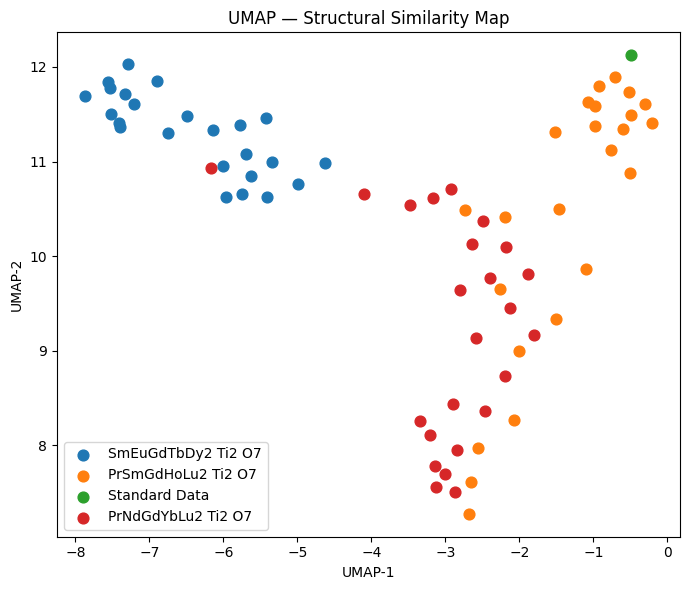

In [72]:
import umap.umap_ as umap

X_umap = umap.UMAP(
    n_neighbors=10,
    min_dist=0.1,
    metric="euclidean",
    random_state=0
).fit_transform(X_scaled)

plt.figure(figsize=(7,6))
for comp in set(labels_composition):
    mask = np.array(labels_composition) == comp
    plt.scatter(X_umap[mask,0], X_umap[mask,1], s=60, label=comp)

plt.title("UMAP — Structural Similarity Map")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
plt.legend()
plt.tight_layout()
plt.show()


Clustering to Identify Phase Regions

In [80]:
X_umap = umap.UMAP(
    n_neighbors=10,
    min_dist=0.1,
    metric="euclidean",
    random_state=0
).fit_transform(X_scaled)

import hdbscan

# Run clustering
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,     # minimum group size considered a phase
    min_samples=5,          # how conservative clustering is
    cluster_selection_epsilon=0.1
).fit(X_umap)

cluster_labels = clusterer.labels_    # -1 means "noise" or transitional states
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)

print(f"Detected number of clusters (structural phases): {n_clusters}")



Detected number of clusters (structural phases): 3


/Users/kbarakat/miniconda3/envs/camm_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kbarakat/miniconda3/envs/camm_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/kbarakat/miniconda3/envs/camm_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


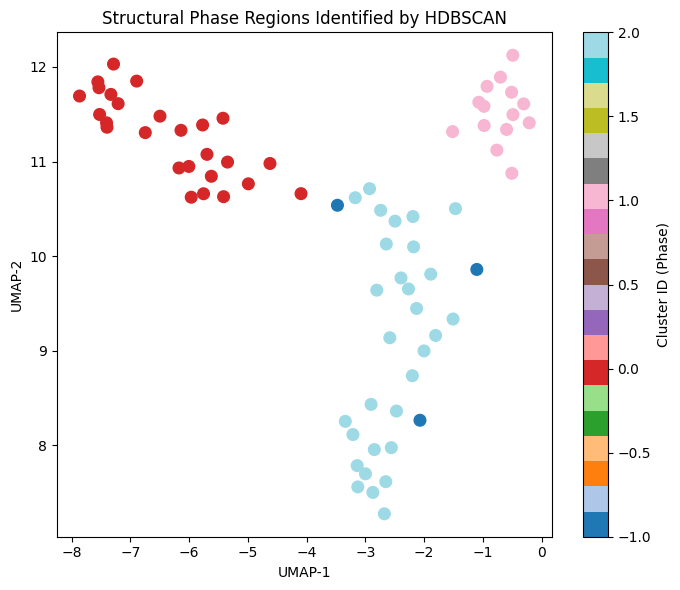

In [81]:
plt.figure(figsize=(7,6))
scatter = plt.scatter(X_umap[:,0], X_umap[:,1], c=cluster_labels, cmap='tab20', s=70)
plt.colorbar(scatter, label="Cluster ID (Phase)")
plt.title("Structural Phase Regions Identified by HDBSCAN")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()


In [82]:
df_clusters = pd.DataFrame({
    "filename": file_names,
    "composition": labels_composition,
    "cluster": cluster_labels
})

display(df_clusters.head())

# Count how many scans from each material fall into each phase
pd.crosstab(df_clusters["composition"], df_clusters["cluster"])


,filename,composition,cluster
0,PrNdGdYbLu_I11_175°C.xrdml,PrNdGdYbLu2 Ti2 O7,2
1,PrNdGdYbLu_I14_225°C.xrdml,PrNdGdYbLu2 Ti2 O7,2
2,PrNdGdYbLu_I17_275°C.xrdml,PrNdGdYbLu2 Ti2 O7,0
3,PrNdGdYbLu_I20_325°C.xrdml,PrNdGdYbLu2 Ti2 O7,2
4,PrNdGdYbLu_I23_375°C.xrdml,PrNdGdYbLu2 Ti2 O7,2


cluster,-1,0,1,2
composition,,,,
PrNdGdYbLu2 Ti2 O7,1,2,0,21
PrSmGdHoLu2 Ti2 O7,2,0,13,9
SmEuGdTbDy2 Ti2 O7,0,24,0,0
Standard Data,0,0,1,0


In [84]:
import re

def parse_formula(name):
    # Keep only the part before Ti/O
    name = name.split("Ti")[0].strip()
    
    matches = re.findall(r"([A-Z][a-z]*)(\d*)", name)
    elements = {}
    
    for element, count in matches:
        count = int(count) if count else 1
        elements[element] = elements.get(element, 0) + count
    
    total = sum(elements.values())
    fractions = {el: c/total for el, c in elements.items()}
    return fractions

for folder in SAMPLE_FOLDERS:
    print(folder, "→", parse_formula(folder))


PrNdGdYbLu2 Ti2 O7 → {'Pr': 0.16666666666666666, 'Nd': 0.16666666666666666, 'Gd': 0.16666666666666666, 'Yb': 0.16666666666666666, 'Lu': 0.3333333333333333}
PrSmGdHoLu2 Ti2 O7 → {'Pr': 0.16666666666666666, 'Sm': 0.16666666666666666, 'Gd': 0.16666666666666666, 'Ho': 0.16666666666666666, 'Lu': 0.3333333333333333}
SmEuGdTbDy2 Ti2 O7 → {'Sm': 0.16666666666666666, 'Eu': 0.16666666666666666, 'Gd': 0.16666666666666666, 'Tb': 0.16666666666666666, 'Dy': 0.3333333333333333}
Standard Data → {'Standard': 0.5, 'Data': 0.5}


BO

In [85]:
import re
from collections import Counter

def parse_formula(name: str):
    # keep only A-site block (before Ti…)
    name = name.split("Ti")[0].strip()
    tokens = re.findall(r"([A-Z][a-z]*)(\d*)", name)
    counts = Counter()
    for el, num in tokens:
        cnt = int(num) if num else 1
        counts[el] += cnt
    total = sum(counts.values())
    fracs = {el: counts[el]/total for el in counts}
    return fracs


In [86]:
import numpy as np
import pandas as pd

# Shannon radii (Å), Ln3+, CN=8 (common for pyrochlore A-site)
RADIUS = {
    "La":1.160,"Ce":1.143,"Pr":1.126,"Nd":1.109,"Pm":1.093,"Sm":1.079,"Eu":1.066,
    "Gd":1.053,"Tb":1.040,"Dy":1.027,"Ho":1.015,"Er":1.004,"Tm":0.994,
    "Yb":0.985,"Lu":0.977,"Y":1.019
}

def composition_features(fracs: dict):
    # keep only ions we know
    items = [(el, x) for el, x in fracs.items() if el in RADIUS and x>0]
    if not items: 
        return dict(r_mean=np.nan, r_var=np.nan, entropy=np.nan, n_species=0)
    xs = np.array([x for _,x in items], float)
    rs = np.array([RADIUS[el] for el,_ in items], float)
    r_mean = float(np.dot(xs, rs))
    r_var  = float(np.dot(xs, (rs - r_mean)**2))          # variance of radius (size disorder)
    entropy = float(-(xs * np.log(xs+1e-12)).sum())       # configurational entropy proxy
    return dict(r_mean=r_mean, r_var=r_var, entropy=entropy, n_species=len(xs))


In [87]:
# labels_composition: list[str] (folder names per scan)
# file_names: list[str]
# cluster_labels: np.ndarray from HDBSCAN (−1 = noise)

rows = []
for comp_name, fname, cl in zip(labels_composition, file_names, cluster_labels):
    fracs = parse_formula(comp_name)
    feats = composition_features(fracs)
    rows.append(dict(file=fname, composition=comp_name, cluster=cl, **feats, **{f"frac_{k}":v for k,v in fracs.items()}))

df = pd.DataFrame(rows)
df_clean = df[df["cluster"]!=-1].copy()   # drop noise for modeling
print(df_clean[["composition","file","cluster","r_mean","r_var","entropy","n_species"]].head())


          composition                        file  cluster    r_mean  \
0  PrNdGdYbLu2 Ti2 O7  PrNdGdYbLu_I11_175°C.xrdml        2  1.037833   
1  PrNdGdYbLu2 Ti2 O7  PrNdGdYbLu_I14_225°C.xrdml        2  1.037833   
2  PrNdGdYbLu2 Ti2 O7  PrNdGdYbLu_I17_275°C.xrdml        0  1.037833   
3  PrNdGdYbLu2 Ti2 O7  PrNdGdYbLu_I20_325°C.xrdml        2  1.037833   
4  PrNdGdYbLu2 Ti2 O7  PrNdGdYbLu_I23_375°C.xrdml        2  1.037833   

      r_var  entropy  n_species  
0  0.003877  1.56071          5  
1  0.003877  1.56071          5  
2  0.003877  1.56071          5  
3  0.003877  1.56071          5  
4  0.003877  1.56071          5  


In [90]:
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

df_model = df_clean.dropna(subset=["r_mean", "r_var"]).copy()

Xc = df_model[["r_mean","r_var"]].to_numpy()
yc = df_model["cluster"].to_numpy()

scaler_c = StandardScaler().fit(Xc)
Xc_s = scaler_c.transform(Xc)

kernel = C(1.0, (1e-3, 1e3)) * RBF([1.0, 1.0], (1e-3, 1e3))
gpc = GaussianProcessClassifier(kernel=kernel, random_state=0, multi_class="one_vs_rest")
gpc.fit(Xc_s, yc)

print("✅ Model fit successful.")
print("Classes learned:", gpc.classes_)


✅ Model fit successful.
Classes learned: [0 1 2]


In [91]:
df_dropped = df_clean[df_clean["r_mean"].isna() | df_clean["r_var"].isna()]
print("Dropped because ionic radius was unknown:")
display(df_dropped[["composition"]].drop_duplicates())


Dropped because ionic radius was unknown:


,composition
72,Standard Data


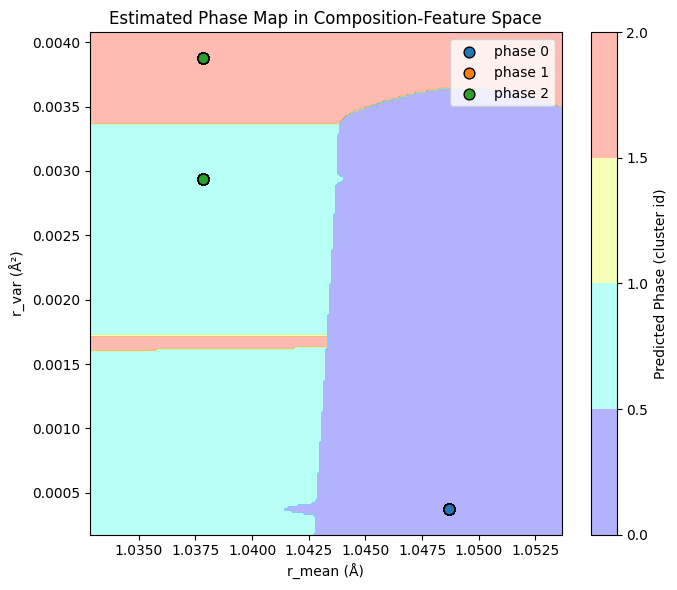

In [ ]:
import matplotlib.pyplot as plt

# grid over observed range
r_mean_min, r_mean_max = df_clean["r_mean"].min(), df_clean["r_mean"].max()
r_var_min,  r_var_max  = df_clean["r_var"].min(),  df_clean["r_var"].max()

R_MEAN, R_VAR = np.meshgrid(
    np.linspace(r_mean_min-0.005, r_mean_max+0.005, 240),
    np.linspace(r_var_min-0.0002, r_var_max+0.0002, 240)
)
Xgrid = np.c_[R_MEAN.ravel(), R_VAR.ravel()]
P = gpc.predict_proba(scaler_c.transform(Xgrid))   # shape: (Npts, n_classes)
Z = gpc.predict(scaler_c.transform(Xgrid)).reshape(R_MEAN.shape)

plt.figure(figsize=(7,6))
cs = plt.contourf(R_MEAN, R_VAR, Z, levels=len(gpc.classes_), alpha=0.3, cmap="jet")
plt.colorbar(cs, label="Predicted Phase (cluster id)")

# overlay training points
for cl in np.unique(yc):
    m = (yc==cl)
    plt.scatter(Xc[m,0], Xc[m,1], s=60, edgecolor='k', label=f"phase {cl}")

plt.xlabel("r_mean (Å)")
plt.ylabel("r_var (Å²)")
plt.title("Estimated Phase Map in Composition-Feature Space")
plt.legend()
plt.tight_layout()
plt.show()

In [94]:
# predictive entropy on the grid
eps = 1e-12
Pmat = P.reshape(R_MEAN.shape + (P.shape[1],))   # HxWxC
H = -(Pmat * np.log(Pmat + eps)).sum(axis=2)     # entropy

# take top K suggestions
K = 10
flat_idx = np.argpartition(H.ravel(), -K)[-K:]
cand = np.c_[R_MEAN.ravel()[flat_idx], R_VAR.ravel()[flat_idx], H.ravel()[flat_idx]]
cand = cand[np.argsort(-cand[:,2])]  # sort by entropy desc

suggestions = pd.DataFrame(cand, columns=["r_mean_target","r_var_target","uncertainty"])
print("Top suggested targets (in r_mean, r_var space):")
print(suggestions.head(10))


Top suggested targets (in r_mean, r_var space):
   r_mean_target  r_var_target  uncertainty
0       1.043381      0.001873     1.098612
1       1.043468      0.002134     1.098612
2       1.043119      0.001139     1.098612
3       1.043294      0.001628     1.098612
4       1.043206      0.001383     1.098612
5       1.043555      0.002396     1.098612
6       1.043206      0.001367     1.098612
7       1.043468      0.002118     1.098612
8       1.043294      0.001612     1.098612
9       1.043555      0.002412     1.098612


In [95]:
import itertools

ION_POOL = ["Pr","Nd","Sm","Eu","Gd","Tb","Dy","Ho","Er","Tm","Yb","Lu","Y"]  # adjust as needed

def mix_features_equal5(combo):
    xs = np.array([0.2]*5)
    rs = np.array([RADIUS[el] for el in combo])
    r_mean = float(np.dot(xs, rs))
    r_var  = float(np.dot(xs, (rs - r_mean)**2))
    return r_mean, r_var

def nearest_equal5_to_targets(targets_df, top_per_target=3):
    # precompute all equal-5 mixes
    mixes, feats = [], []
    for comb in itertools.combinations(ION_POOL, 5):
        rm, rv = mix_features_equal5(comb)
        mixes.append(comb)
        feats.append((rm, rv))
    feats = np.array(feats)

    out_rows = []
    for _, row in targets_df.iterrows():
        t = np.array([row["r_mean_target"], row["r_var_target"]])
        d = np.linalg.norm(feats - t, axis=1)
        idx = np.argsort(d)[:top_per_target]
        for j in idx:
            out_rows.append(dict(
                r_mean_target=row["r_mean_target"],
                r_var_target=row["r_var_target"],
                uncertainty=row["uncertainty"],
                proposal=" + ".join(mixes[j]),
                r_mean_proposal=feats[j,0],
                r_var_proposal=feats[j,1],
                distance=float(d[j])
            ))
    return pd.DataFrame(out_rows).sort_values(["uncertainty","distance"], ascending=[False, True])

proposals = nearest_equal5_to_targets(suggestions.head(5), top_per_target=5)
proposals.head(15)


,r_mean_target,r_var_target,uncertainty,proposal,r_mean_proposal,r_var_proposal,distance
0,1.043381,0.001873,1.098612,Pr + Gd + Ho + Er + Y,1.0434,0.001974,0.000102
1,1.043381,0.001873,1.098612,Nd + Eu + Gd + Er + Yb,1.0434,0.001974,0.000102
2,1.043381,0.001873,1.098612,Nd + Sm + Ho + Tm + Y,1.0432,0.001883,0.000181
3,1.043381,0.001873,1.098612,Pr + Tb + Dy + Er + Y,1.0432,0.001850,0.000182
4,1.043381,0.001873,1.098612,Nd + Sm + Tb + Er + Yb,1.0434,0.002109,0.000237
5,1.043468,0.002134,1.098612,Nd + Sm + Tb + Er + Yb,1.0434,0.002109,0.000072
6,1.043468,0.002134,1.098612,Pr + Gd + Tb + Er + Tm,1.0434,0.002184,0.000084
7,1.043468,0.002134,1.098612,Nd + Eu + Gd + Er + Yb,1.0434,0.001974,0.000174
8,1.043468,0.002134,1.098612,Pr + Gd + Ho + Er + Y,1.0434,0.001974,0.000174
9,1.043468,0.002134,1.098612,Pr + Eu + Dy + Er + Tm,1.0434,0.002319,0.000197


# XRD data from Dr Claudia Rawn

In [ ]:
!gdown --fuzzy https://drive.google.com/file/d/1RP9hezq8hVuTuPj-_Qy9zvbSDTSgHw7E/view?usp=sharing

In [ ]:
!unzip '/content/XRD Data for CAMM hackathon_Rawn.zip' -d /content/XRD_Hackathon_Rawn

In [ ]:
import os, textwrap

BASE = "/content/XRD_Hackathon_Rawn"
for d in sorted(os.listdir(BASE)):
    p = os.path.join(BASE, d)
    mark = "📁" if os.path.isdir(p) else "📄"
    print(f"{mark} {d}")


In [ ]:
# --- Choose any .xrdml file from the folder ---
import matplotlib.pyplot as plt

file = "(YPrNdHoTm)3Al5O12 PSE.xrdml"  # 👈 change this
df = read_xrdml_df(os.path.join(BASE, file))

plt.figure(figsize=(6,4))
plt.plot(df["2theta_deg"], df["intensity"])
plt.xlabel("2θ (°)")
plt.ylabel("Intensity (a.u.)")
plt.title(file)
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(7,5))
for f in sorted(os.listdir(BASE)):
    if f.lower().endswith(".xrdml"):
        try:
            df = read_xrdml_df(os.path.join(BASE, f))
            plt.plot(df["2theta_deg"], df["intensity"], label=f.split()[0])
        except Exception:
            continue
plt.xlabel("2θ (°)")
plt.ylabel("Intensity (a.u.)")
plt.legend()
plt.title("All XRD patterns in folder")
plt.tight_layout()
plt.show()


# CIF file info
To get some info on the .cif file, use the code below

In [ ]:
file = "/content/XRD_Hackathon_Rawn/Al2O3 30024.cif"  # 👈 change this
with open(os.path.join(BASE, file)) as f:
    print(f.read()[:400], "...")
